# Code for reproducing Figure 1 plots
## This notebooks depend on first generating the processed and clustered data

last updated: 20241125

## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set a path to your working directory
directory='/Set/your/path/'

# load .h5ad with processed data 
adata = sc.read_h5ad(directory+'/Written_files/D16_GEX_processed-clustered.h5ad')

print(adata)

AnnData object with n_obs × n_vars = 73077 × 40500
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden'
    var: 'gene_ids-D16_CH2_Chimp', 'feature_types-D16_CH2_Chimp', 'genome-D16_CH2_Chimp', 'gene_ids-D16_CH2_Human', 'feature_types-D16_CH2_Human', 'genome-D16_CH2_Human', 'gene_ids-D16_CH_Chimp', 'feature_types-D16_CH_Chimp', 'genome-D16_CH_Chimp', 'gene_ids-D16_CH_Human', 'feature_types-D16_CH_Human', 'genome-D16_CH_Human', 'gene_ids-D16_M0_5_Chimp', 'feature_types-D16_M0_5_Chimp', 'genome-D16_M0_5_Chimp', 'gene_ids-D16_M0_5_Human', 'feature_types-D16_M0_5_Human', 'genome-D16_M0_5_Human', 'gene_ids-D16_M0_5_Orangutan', 'feature_types-D16_M0_5_Orangutan', 'genome-D16_M0_5_Orangutan', 'gene_ids-D16_M0_5_Rhesus', 'feature_types-D16_M0_5_Rhesus', 'genome-D16_M0_5_Rhesus', 'gene_ids-D16_M2_Chimp', 'feature_types-D16_M2

# Figure panel 1D

Proportions of all individuals at D16, post quality control and doublet removal. Human lines: H9, H20961, H21194, H21792, H23555, H28126, H28334, H29089; Chimpanzee lines: C3624, C3651, C4933, C8861, C40210, C40300, C40670; Orangutan line: O11045-4593; Macaque lines: LYON-ES1, ZG15-M11-10, ZH26-HS16.


In [3]:
# Create obs species_individual
species_individual = pd.Categorical(adata.obs['species'].astype(str) + ('_') + adata.obs['individual'].astype(str))
adata.obs['species_individual'] = species_individual

# Create obs species_individual
adata.obs['time_point'] = 'D16'

<Figure size 432x288 with 0 Axes>

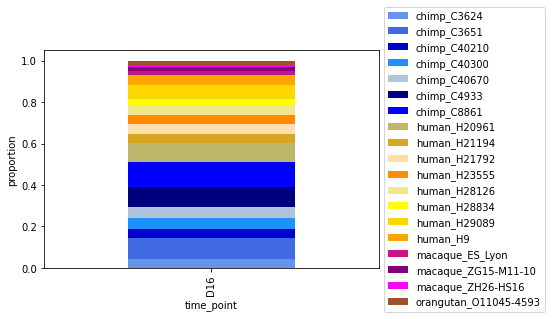

In [4]:
# only plot cells with assigned identity
adata_D16_proportion = adata[~adata.obs['species_individual'].isin(['chimp_nan','human_nan', 'macaque_nan'])]

# Set color scheme
custom_colors = {
    'chimp_C3624': 'cornflowerblue',
    'chimp_C3651': 'royalblue',
    'chimp_C4933': 'navy',
    'chimp_C8861': 'blue',
    'chimp_C40210': 'mediumblue',
    'chimp_C40300': 'dodgerblue',
    'chimp_C40670': 'lightsteelblue',
    'human_H9': 'orange',
    'human_H20961': 'darkkhaki',
    'human_H21194': 'goldenrod',
    'human_H21792': 'navajowhite',
    'human_H23555': 'darkorange',
    'human_H28126': 'khaki',
    'human_H28834': 'yellow',
    'human_H29089': 'gold',
    'macaque_ZG15-M11-10': 'purple',
    'macaque_ES_Lyon': 'mediumvioletred',
    'macaque_ZH26-HS16': 'magenta',
    'orangutan_O11045-4593': 'sienna',
}


f = plt.figure()
df_plot = adata_D16_proportion.obs.groupby(['species_individual', 'time_point']).size().reset_index().pivot(columns='species_individual', index='time_point', values=0).apply(lambda g: g / g.sum(), 1)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax=df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()

# Figure panel 1H

UMAP of cells collected at D16, colored by MULTI-seq barcode identity which corresponds to the applied CHIR99021 concentration. 

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


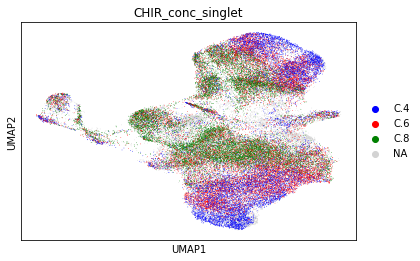

In [5]:
# Create obs CHIR_conc_singlet
adata.obs['CHIR_conc_singlet'] = np.nan
adata.obs.loc[adata.obs['demux_type'] == 'singlet','CHIR_conc_singlet'] = adata.obs.loc[adata.obs['demux_type'] == 'singlet',:]['CHIR_conc']

# Remove cells from replicate expeiment
adata_main_exp = adata[~adata.obs['CHIR_conc_singlet'].isin(['C.5'])]

# color UMAP based on CHIR conc
sc.pl.umap(adata_main_exp, save='_D16_CHIR.png', color='CHIR_conc_singlet', 
            palette={
        "C.4": "blue",
        "C.6": "red",
        "C.8": "green",
        })


# Figure panel 1J

UMAPs of cells collected at D16, colored by key genes to determine rostral-caudal identity. 

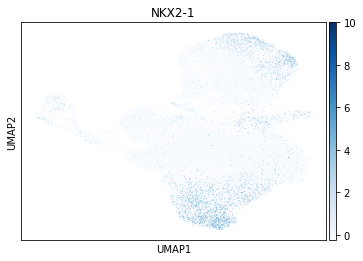

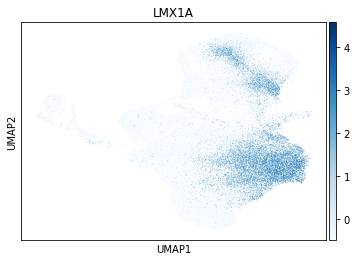

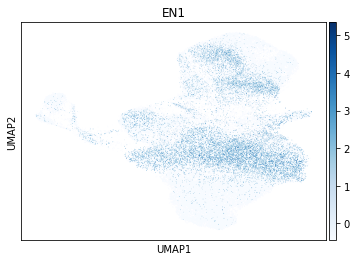

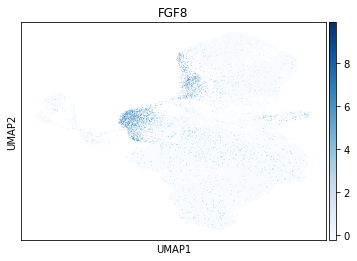

In [6]:
# color UMAP based on genes of interest, save as svg to enable overlaying figures
sc.pl.umap(adata, color=['NKX2-1'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_NKX2-1.svg')
sc.pl.umap(adata, color=['LMX1A'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_LMX1A.svg',)
sc.pl.umap(adata, color=['EN1'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_EN1.svg',)
sc.pl.umap(adata, color=['FGF8'], use_raw=False, color_map=matplotlib.cm.Blues, 
           save='_D16_FGF8.svg',)

# Figure panel 1K

Dotplot of the expression of cell type markers for the assigned cluster identities at D16 and bar chart of the contribution of individuals to the different cell types

In [7]:
# assign cell type names to each of the leiden clusters
labeldict={'0':'9. Caudal vMB progenitors',
           '1':'6. vMB progenitors',
           '2':'6. vMB progenitors',
           '3':'1. vFB progenitors',
           '4':'7. vMB progenitors (cycling, G1/S phase)',
           '5':'4. Caudal vFB/rostral vMB progenitors',
           '6':'1. vFB progenitors',
           '7':'10. vMB/BP progenitors',
           '8':'3. vFB progenitors (cycling, M/G2 phase)',
           '9':'12. Rostral vHB progenitors',
           '10':'15. Progenitors (subtype unknown)',
           '11':'8. vMB progenitors (cycling, M/G2 phase)',
           '12':'6. vMB progenitors',
           '13':'13. vHB progenitors (cycling)',
           '14':'5. vFB/vMB progenitors (cycling)',
           '15':'8. vMB progenitors (cycling, M/G2 phase)',
           '16':'2. vFB progenitors (cycling, G1/S phase)',
           '17':'11. vMB/vHB progenitors',
           '18':'17. Glutamatergic neurons',
           '19':'14. Progenitors (high ECM/Actin-regulation)',
           '20':'16. Immature neurons and motor neurons',
           '21':'5. vFB/vMB progenitors (cycling)',
           '22':'6. vMB progenitors',

           }

adata.obs['cell_type']=[labeldict[x] for x in adata.obs['leiden']]

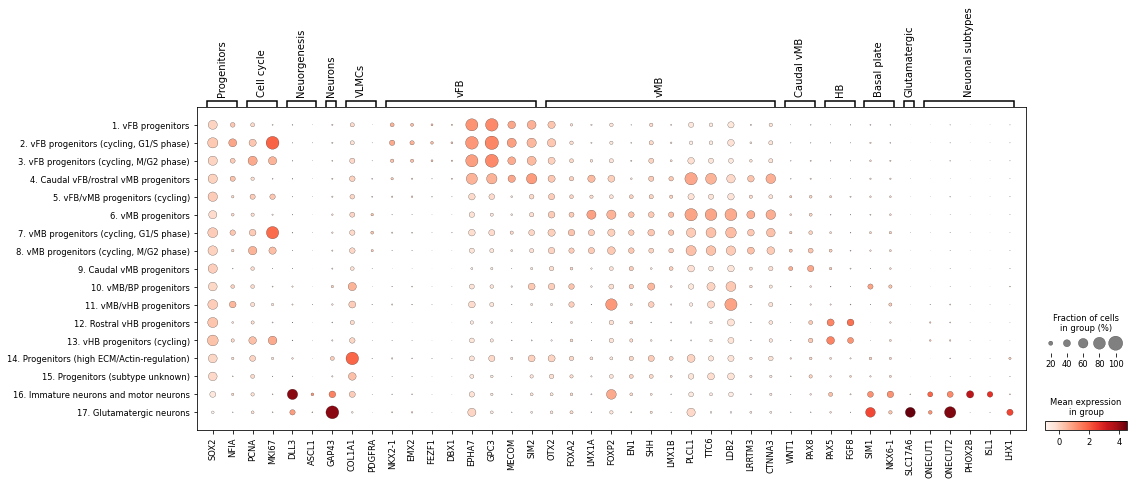

In [9]:
# Generate a dotplot of marker gene expression in the assigned cell types
summary_markers = {
    'Progenitors':['SOX2', 'NFIA'],
    'Cell cycle': ['PCNA', 'MKI67'],
    'Neuorgenesis':['DLL3', 'ASCL1'],
    'Neurons':['GAP43'],
    'VLMCs':['COL1A1', 'PDGFRA'],
    'vFB':['NKX2-1', 'EMX2', 'FEZF1', 'DBX1', 'EPHA7','GPC3', 'MECOM', 'SIM2' ],
    'vMB': ['OTX2', 'FOXA2', 'LMX1A','FOXP2', 'EN1', 'SHH', 'LMX1B', 'PLCL1', 'TTC6', 'LDB2', 'LRRTM3', 'CTNNA3'],
    'Caudal vMB': ['WNT1','PAX8'],
    'HB':['PAX5','FGF8'], 
    'Basal plate': ['SIM1','NKX6-1'],
    'Glutamatergic': ['SLC17A6'],
    'Neuonal subtypes': ['ONECUT1','ONECUT2', 'PHOX2B','ISL1',  'LHX1']
                
}

sc.pl.dotplot(adata, summary_markers, use_raw=False,  groupby='cell_type', save='_D16_markergenes.pdf')

/var/folders/3f/qnn57wjj4f330myjp0cbvc780000gp/T/ipykernel_18135/115947201.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_D16_proportion.obs['cell_type']=[labeldict[x] for x in adata_D16_proportion.obs['leiden']]


<Figure size 432x288 with 0 Axes>

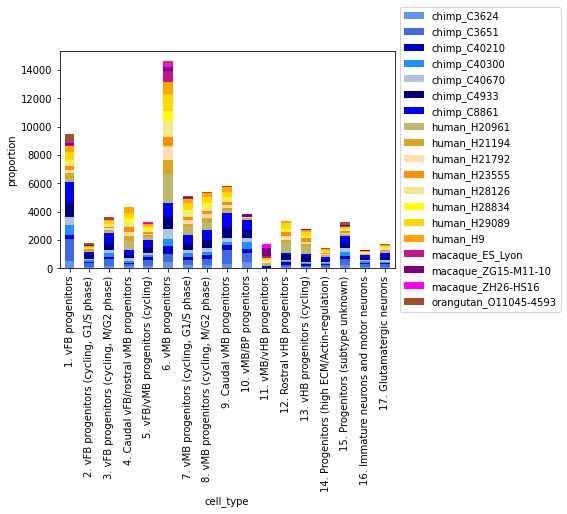

In [9]:
# Add celltype names to adata_D16_proportion object
adata_D16_proportion.obs['cell_type']=[labeldict[x] for x in adata_D16_proportion.obs['leiden']]

f = plt.figure()
df_plot = adata_D16_proportion.obs.groupby(['species_individual', 'cell_type']).size().reset_index().pivot(columns='species_individual', index='cell_type', values=0)

# Define the custom order for cell types
ordered_cell_types = ['1. vFB progenitors','2. vFB progenitors (cycling, G1/S phase)','3. vFB progenitors (cycling, M/G2 phase)',
                     '4. Caudal vFB/rostral vMB progenitors','5. vFB/vMB progenitors (cycling)','6. vMB progenitors',
                     '7. vMB progenitors (cycling, G1/S phase)','8. vMB progenitors (cycling, M/G2 phase)','9. Caudal vMB progenitors',
                     '10. vMB/BP progenitors','11. vMB/vHB progenitors','12. Rostral vHB progenitors','13. vHB progenitors (cycling)',
                     '14. Progenitors (high ECM/Actin-regulation)','15. Progenitors (subtype unknown)', '16. Immature neurons and motor neurons',
                     '17. Glutamatergic neurons'] 

# Reorder the rows of df_plot based on the custom order
df_plot = df_plot.reindex(ordered_cell_types)

# Extract individual names from the columns
individuals = df_plot.columns

# Create a list of colors based on the custom_colors dictionary
colors = [custom_colors.get(individual, None) for individual in individuals]

# Filter out None values (default_color) from the list
colors = [color for color in colors if color is not None]

ax = df_plot.plot(kind='bar', stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.ylabel('proportion')

plt.show()